# CASME3 → ROI → POC-ABS / 4QMV → Excel

Pipeline:
1. Discover semua clip dari dataset
2. Per clip, **semua frame**: detect face + landmark → crop 3 ROI → save semua ROI image
3. Frame[0] sebagai baseline, frame[1..N] dibandingkan via POC → Vektor → Quadran
4. Semua clip digabung jadi **2 file Excel** (`poc_abs_flatten.xlsx` + `poc_abs_quadran_sum.xlsx`)
5. Multiprocessing untuk speed


In [1]:
import sys, os
from pathlib import Path

ROOT = Path(os.getcwd()).resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent.parent
elif ROOT.name == "comparasion":
    ROOT = ROOT.parent
elif ROOT.name in {"lstm", "svm", "knn"}:
    ROOT = ROOT.parent.parent.parent
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print(f"Project root: {ROOT}")

Project root: /home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st


In [2]:
from collections import Counter

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from comparasion.core.config import ComparisonConfig
from comparasion.core.dataset import discover_clips
from comparasion.core.pipeline import run_dataset_parallel
from comparasion.core.roi import ROIExtractor

## Config

In [3]:
DATASET_ROOT = Path("comparasion/dataset/CASME2")
N_PROC = 6  # jumlah worker parallel

config = ComparisonConfig()

print(f"Dataset:     {DATASET_ROOT}")
print(f"Output:      {config.output_root}")
print(f"ROI out:     {config.roi_output_dir}")
print(f"Feature out: {config.feature_output_dir}")
print(f"Regions:     {list(config.regions.keys())}")
print(f"Block size:  {config.block_size}")
print(f"Workers:     {N_PROC}")

Dataset:     comparasion/dataset/CASME2
Output:      comparasion/output_casme2
ROI out:     comparasion/output_casme2/roi
Feature out: comparasion/output_casme2/features
Regions:     ['mulut', 'mata_kiri', 'mata_kanan', 'alis_kiri', 'alis_kanan']
Block size:  7
Workers:     6


## Discover clips

In [4]:
clips = discover_clips(DATASET_ROOT)
print(f"Total clips: {len(clips)}\n")

for emo, cnt in sorted(Counter(c.emotion for c in clips).items()):
    print(f"  {emo}: {cnt}")

Total clips: 28

  Disgust: 7
  Happiness: 7
  Sadness: 7
  Surprise: 7


## Run pipeline (parallel)

Per clip: extract ROI **semua frame** → POC vs baseline → gabung semua ke 2 Excel.


In [5]:
processed, errors = run_dataset_parallel(clips, config, n_proc=N_PROC)

print(f"Done: {processed}/{len(clips)} clips")
print(f"Errors: {len(errors)}")

Done: 28/28 clips
Errors: 0


In [6]:
if errors:
    print(f"Total errors: {len(errors)}\n")
    for sid, msg in errors[:20]:
        print(f"  {sid}: {msg}")
    if len(errors) > 20:
        print(f"  ... +{len(errors) - 20} lainnya")

## Verifikasi output

In [7]:
feat_out = config.feature_output_dir
roi_out = config.roi_output_dir

print("=== Feature Excel (combined) ===")
for f in sorted(feat_out.glob("*.xlsx")):
    df = pd.read_excel(f)
    print(f"  {f.name}: {df.shape[0]} rows x {df.shape[1]} cols")

print(f"\n=== ROI images ===")
for emo_dir in sorted(roi_out.iterdir()):
    if emo_dir.is_dir():
        n = len(list(emo_dir.rglob("*.jpg")))
        print(f"  {emo_dir.name}: {n} images")
print(f"Total: {len(list(roi_out.rglob('*.jpg')))} images")

=== Feature Excel (combined) ===
  poc_abs_flatten.xlsx: 1151 rows x 613 cols
  poc_abs_quadran_sum.xlsx: 1151 rows x 145 cols

=== ROI images ===
  Disgust: 1310 images
  Happiness: 1560 images
  Sadness: 1370 images
  Surprise: 1655 images
Total: 5895 images


In [8]:
# sanity check: poc_abs_flatten (POC-ABS, nanti input PCA)
df_flat = pd.read_excel(feat_out / "poc_abs_flatten.xlsx")
print(f"poc_abs_flatten: {df_flat.shape}")
print(f"Emotions: {sorted(df_flat['emotion'].unique())}")
print(f"Subjects: {df_flat['subject'].nunique()}")
df_flat.head()

poc_abs_flatten: (1151, 613)
Emotions: ['Disgust', 'Happiness', 'Sadness', 'Surprise']
Subjects: 13


,emotion,subject,clip,frame,mulut_x1,mulut_y1,mulut_t1,mulut_m1,mulut_x2,mulut_y2,...,alis_kanan_m25,alis_kanan_x26,alis_kanan_y26,alis_kanan_t26,alis_kanan_m26,alis_kanan_x27,alis_kanan_y27,alis_kanan_t27,alis_kanan_m27,label
0,Disgust,20,20_EP06_03,2,0,0,0.0,0.0,0,0,...,0.0,0,0,0.0,0.0,0,0,0.0,0.0,Disgust
1,Disgust,20,20_EP06_03,3,0,0,0.0,0.0,2,0,...,1.0,0,0,0.0,0.0,0,0,0.0,0.0,Disgust
2,Disgust,20,20_EP06_03,4,-1,0,180.0,1.0,0,0,...,1.0,0,0,0.0,0.0,0,0,0.0,0.0,Disgust
3,Disgust,20,20_EP06_03,5,0,0,0.0,0.0,0,0,...,3.0,1,0,0.0,1.0,0,0,0.0,0.0,Disgust
4,Disgust,20,20_EP06_03,6,0,0,0.0,0.0,1,0,...,1.0,0,0,0.0,0.0,0,0,0.0,0.0,Disgust


In [9]:
# sanity check: poc_abs_quadran_sum (4QMV)
df_quad = pd.read_excel(feat_out / "poc_abs_quadran_sum.xlsx")
print(f"poc_abs_quadran_sum: {df_quad.shape}")
print(f"Columns: {list(df_quad.columns)}")
df_quad.head()

poc_abs_quadran_sum: (1151, 145)
Columns: ['emotion', 'subject', 'clip', 'frame', 'mulut_Q1_x', 'mulut_Q1_y', 'mulut_Q1_m', 'mulut_Q1_cos_t', 'mulut_Q1_sin_t', 'mulut_Q1_mean_theta', 'mulut_Q1_count', 'mulut_Q2_x', 'mulut_Q2_y', 'mulut_Q2_m', 'mulut_Q2_cos_t', 'mulut_Q2_sin_t', 'mulut_Q2_mean_theta', 'mulut_Q2_count', 'mulut_Q3_x', 'mulut_Q3_y', 'mulut_Q3_m', 'mulut_Q3_cos_t', 'mulut_Q3_sin_t', 'mulut_Q3_mean_theta', 'mulut_Q3_count', 'mulut_Q4_x', 'mulut_Q4_y', 'mulut_Q4_m', 'mulut_Q4_cos_t', 'mulut_Q4_sin_t', 'mulut_Q4_mean_theta', 'mulut_Q4_count', 'mata_kiri_Q1_x', 'mata_kiri_Q1_y', 'mata_kiri_Q1_m', 'mata_kiri_Q1_cos_t', 'mata_kiri_Q1_sin_t', 'mata_kiri_Q1_mean_theta', 'mata_kiri_Q1_count', 'mata_kiri_Q2_x', 'mata_kiri_Q2_y', 'mata_kiri_Q2_m', 'mata_kiri_Q2_cos_t', 'mata_kiri_Q2_sin_t', 'mata_kiri_Q2_mean_theta', 'mata_kiri_Q2_count', 'mata_kiri_Q3_x', 'mata_kiri_Q3_y', 'mata_kiri_Q3_m', 'mata_kiri_Q3_cos_t', 'mata_kiri_Q3_sin_t', 'mata_kiri_Q3_mean_theta', 'mata_kiri_Q3_count', '

,emotion,subject,clip,frame,mulut_Q1_x,mulut_Q1_y,mulut_Q1_m,mulut_Q1_cos_t,mulut_Q1_sin_t,mulut_Q1_mean_theta,...,alis_kanan_Q3_mean_theta,alis_kanan_Q3_count,alis_kanan_Q4_x,alis_kanan_Q4_y,alis_kanan_Q4_m,alis_kanan_Q4_cos_t,alis_kanan_Q4_sin_t,alis_kanan_Q4_mean_theta,alis_kanan_Q4_count,label
0,Disgust,20,20_EP06_03,2,6,1,6.162,2.915295,-0.402784,-0.137293,...,-2.212374,1,2,-5,5.828,3.620061,0.216995,0.059871,4,Disgust
1,Disgust,20,20_EP06_03,3,3,0,3.000,2.000000,0.000000,0.000000,...,-1.194671,1,1,-2,2.236,0.310297,0.950640,1.255291,1,Disgust
2,Disgust,20,20_EP06_03,4,2,3,4.162,0.229793,0.637794,1.224981,...,-2.212374,1,3,-1,3.162,-0.645897,0.763425,2.272993,1,Disgust
3,Disgust,20,20_EP06_03,5,3,2,3.606,-0.646721,0.762727,2.274073,...,-2.212374,2,0,-3,3.000,0.984382,-0.176046,-0.176968,1,Disgust
4,Disgust,20,20_EP06_03,6,4,2,4.606,0.353279,0.762727,1.137037,...,-2.212374,2,0,0,0.000,0.000000,0.000000,0.000000,0,Disgust


In [10]:
# cek jumlah ROI per region untuk clip pertama
clip = clips[0]
sid = clip.sample_id
emo = clip.emotion

clip_roi_dir = roi_out / emo / sid
for region in sorted(os.listdir(clip_roi_dir)):
    files = sorted(os.listdir(clip_roi_dir / region))
    print(f"  {region}: {len(files)} frames")

  alis_kanan: 41 frames
  alis_kiri: 41 frames
  mata_kanan: 41 frames
  mata_kiri: 41 frames
  mulut: 41 frames


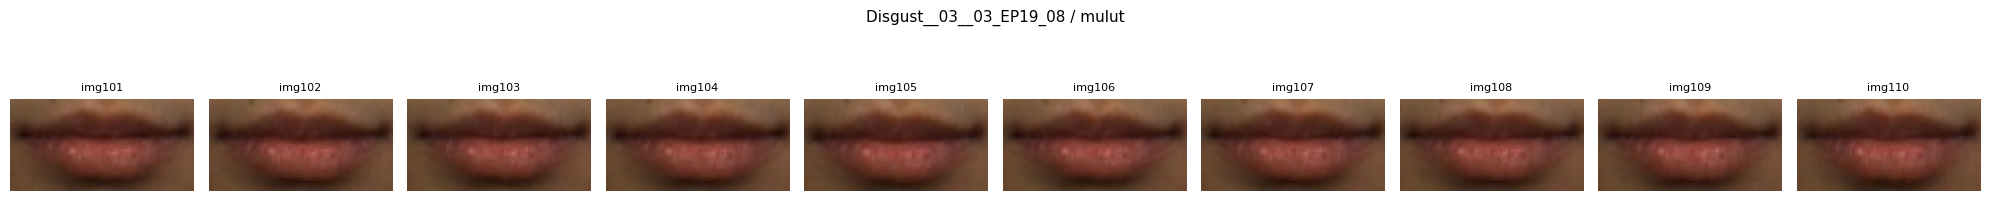

In [11]:
# visual: ROI semua frame dari 1 region clip pertama (max 10)
region = "mulut"
region_dir = clip_roi_dir / region
frame_files = sorted(os.listdir(region_dir))[:10]

n = len(frame_files)
fig, axes = plt.subplots(1, n, figsize=(2 * n, 2.5))
if n == 1:
    axes = [axes]
for ax, fname in zip(axes, frame_files):
    img = cv2.cvtColor(cv2.imread(str(region_dir / fname)), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(fname.replace(".jpg", ""), fontsize=8)
    ax.axis("off")

fig.suptitle(f"{sid} / {region}", fontsize=11)
plt.tight_layout()
plt.show()